# Analysis of parking occupancy
Compared to archive: Take base occupancy as parking supply and analyse the relative overshoot during the policy case.

In [23]:
import pandas as pd
%config InlineBackend.figure_format = 'retina'

base_path="/Users/paulh/runs-svn/matsim-berlin/autofrei/1pct-v6.4/berlin-autofrei-v6.4-baseCaseCtdExtended/"
base_parking = pd.read_csv(base_path + "parking_occupancy_autofrei-1pct.csv.zst")

policy_parking = pd.read_csv("/Users/paulh/runs-svn/matsim-berlin/autofrei/1pct-v6.4/berlin-autofrei-v6.4-policy/parking_occupancy_autofrei-1pct.csv.zst")

pct=0.01

In [20]:
# join base and policy on linkId.
merged = base_parking.merge(policy_parking, on="linkId", suffixes=("_base", "_policy"))
merged["occupancy_diff"] = merged["occupancy_policy"] - merged["occupancy_base"]
merged["relative_overshoot"] = merged["occupancy_diff"] / merged["occupancy_base"].replace(0, pd.NA)  # avoid division by zero, set to NA
merged

,linkId,from_time_base,to_time_base,length_base,occupancy_base,initial_base,from_time_policy,to_time_policy,length_policy,occupancy_policy,initial_policy,occupancy_diff,relative_overshoot
0,-218722226,23908.0,26274.0,851.81,1.0,0.0,23717.0,26083.0,851.81,1.0,0.0,0.0,0.0
1,-458915637#0,46210.0,47899.0,213.59,3.0,1.0,39208.0,46787.0,213.59,2.0,1.0,-1.0,-0.333333
2,-25436865#3,34062.0,40611.0,221.24,1.0,0.0,34032.0,40611.0,221.24,1.0,0.0,0.0,0.0
3,15805101#0,72746.0,73446.0,91.18,1.0,0.0,75876.0,76576.0,91.18,1.0,0.0,0.0,0.0
4,1117976084,53124.0,53459.0,144.20,1.0,0.0,52869.0,53204.0,144.20,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21395,-141317918,73808.0,74322.0,140.81,1.0,0.0,72959.0,74621.0,140.81,1.0,0.0,0.0,0.0
21396,-153608616#1,44519.0,46754.0,158.07,1.0,0.0,44516.0,46751.0,158.07,1.0,0.0,0.0,0.0
21397,22962092,64636.0,67811.0,114.89,1.0,0.0,71327.0,74502.0,114.89,1.0,0.0,0.0,0.0
21398,-25814594#0,26032.0,50884.0,190.92,1.0,0.0,26285.0,50884.0,190.92,1.0,0.0,0.0,0.0


In [39]:
import geopandas as gpd

df_links = pd.read_csv(
    base_path + "berlin-v6.4.output_links.csv.zst",
    sep=";",
    compression="zstd",
    dtype={"link": "string"},
    low_memory=False,
)

links = gpd.GeoDataFrame(
    df_links[~df_links["link"].str.contains("pt_")],
    geometry=gpd.GeoSeries.from_wkt(df_links["geometry"], crs="EPSG:25832"),
)
links

,link,from_node,to_node,length,freespeed,capacity,lanes,modes,vol_car,vol_commercial_goods_car,...,vol_truck,allowed_speed,maxInflowUsedInQsim,name,speed_factor,restricted_lanes,hbefa_road_type,storageCapacityUsedInQsim,type,geometry
0,-1000055665,6773970060,267855868,28.01,4.634,634.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",0,0,...,0,13.89,1053.102038,Lindenweg,4.634,NaN,URB/Access/50,NaN,highway.residential,"LINESTRING (796573.1 5797464.9, 796580.93 5797..."
1,-1000098209,29266788,29266795,58.56,2.554,800.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",0,0,...,0,2.78,760.043646,Lilli-Henoch-Straße,2.554,NaN,URB/Access/30,0.082185,highway.living_street,"LINESTRING (800578.77 5830375.13, 800629.32 58..."
2,-100012092,2288369966,1017979482,223.51,9.344,1896.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",0,0,...,0,13.89,1383.203395,Dorfstraße,9.344,NaN,URB/Local/50,0.408496,highway.tertiary,"LINESTRING (807040 5714450.85, 806856.97 57145..."
3,-1000121005,9231911647,3869622346,136.97,10.460,1933.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",15,3,...,0,13.89,1430.264357,Lichtenrader Straße,10.460,NaN,URB/Access/50,0.246820,highway.unclassified,"LINESTRING (799342.3 5811143.42, 799386.89 581..."
4,-1000268036,94673071,7829689846,69.88,7.133,800.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",1,5,...,0,8.33,1262.515118,Roseggerstraße,7.133,NaN,URB/Access/30,NaN,highway.residential,"LINESTRING (802003.09 5823888.17, 801962.85 58..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213956,999753858,cluster_10219572135_247947537_4796865042_80644...,8310059767,21.17,3.231,1666.0,1.0,bike,0,0,...,0,5.56,873.518677,NaN,3.231,NaN,URB/Access/30,0.053835,highway.cycleway,"LINESTRING (809649.3 5829245.86, 809633.22 582..."
213957,999943085,9135760767,cluster_9193459685_95920977,165.26,5.561,1412.0,1.0,bike,0,0,...,0,5.56,1143.336874,NaN,5.561,NaN,URB/Access/30,0.272124,highway.path,"LINESTRING (813176.2 5831254, 813018.57 583120..."
213958,999943090#1,cluster_9193459685_95920977,cluster_9196165417_95920978,147.05,5.625,1412.0,1.0,bike,0,0,...,0,5.56,1148.936170,NaN,5.625,NaN,URB/Access/30,0.240959,highway.path,"LINESTRING (813018.57 5831208.39, 812877.65 58..."
213959,999948146#1,258956777,268072032,175.76,7.158,800.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",3,0,...,0,8.33,1264.143168,Goethestraße,7.158,NaN,URB/Access/30,NaN,highway.residential,"LINESTRING (801940.36 5803217.47, 802026.89 58..."


In [61]:
# join merged with links on linkId and link, keep all columns
final = links.merge(merged, left_on="link", right_on="linkId", how="left")
final_3857 = final.to_crs(epsg=3857)
final_3857["geometry"] = final_3857.geometry.simplify(2)
# final_3857["relative_overshoot"] = final_3857["relative_overshoot"]
final_3857[final_3857["link"]=="306046325"]

,link,from_node,to_node,length,freespeed,capacity,lanes,modes,vol_car,vol_commercial_goods_car,...,length_base,occupancy_base,initial_base,from_time_policy,to_time_policy,length_policy,occupancy_policy,initial_policy,occupancy_diff,relative_overshoot
153809,306046325,cluster_1124813895_1124813897_619470643,26852178,19.12,5.992,529.0,1.0,"bike,car,commercial_goods_car,freight,ride,truck",3,12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Number of links with relative overshoot > 4: 34
Percentiles of relative_overshoot:
0.250    0.0
0.500    0.0
0.750    0.0
0.900    0.0
0.950    0.0
0.990    1.0
0.999    6.0
Name: relative_overshoot, dtype: object


<Axes: ylabel='Frequency'>

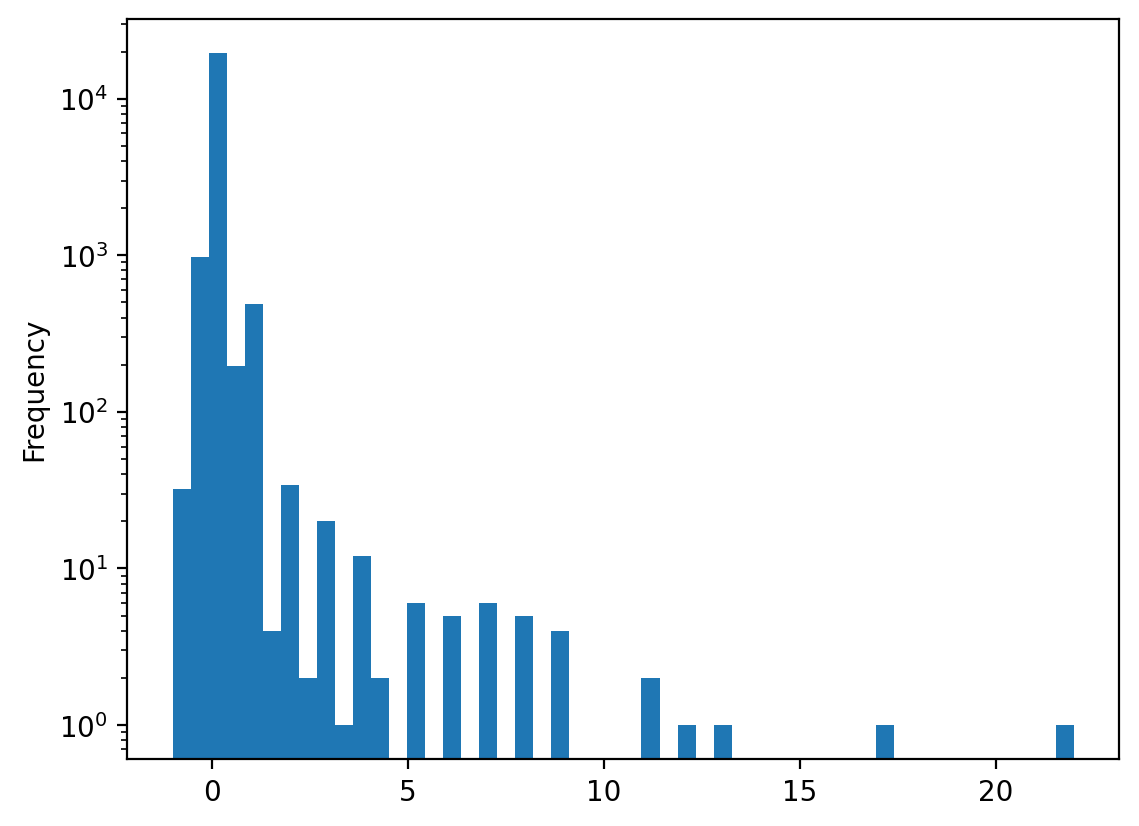

In [64]:
# count how many links have a relative_overshoot of >4
num_links_overshoot = (final_3857["relative_overshoot"] > 4).sum()
print(f"Number of links with relative overshoot > 4: {num_links_overshoot}")

# print percentiles of relative_overshoot
percentiles = final_3857["relative_overshoot"].quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.999])
print("Percentiles of relative_overshoot:")
print(percentiles)

# make a hist plot of relative_overshoot, excluding NA values and log y axis
final_3857["relative_overshoot"].dropna().plot.hist(bins=50, log=True)

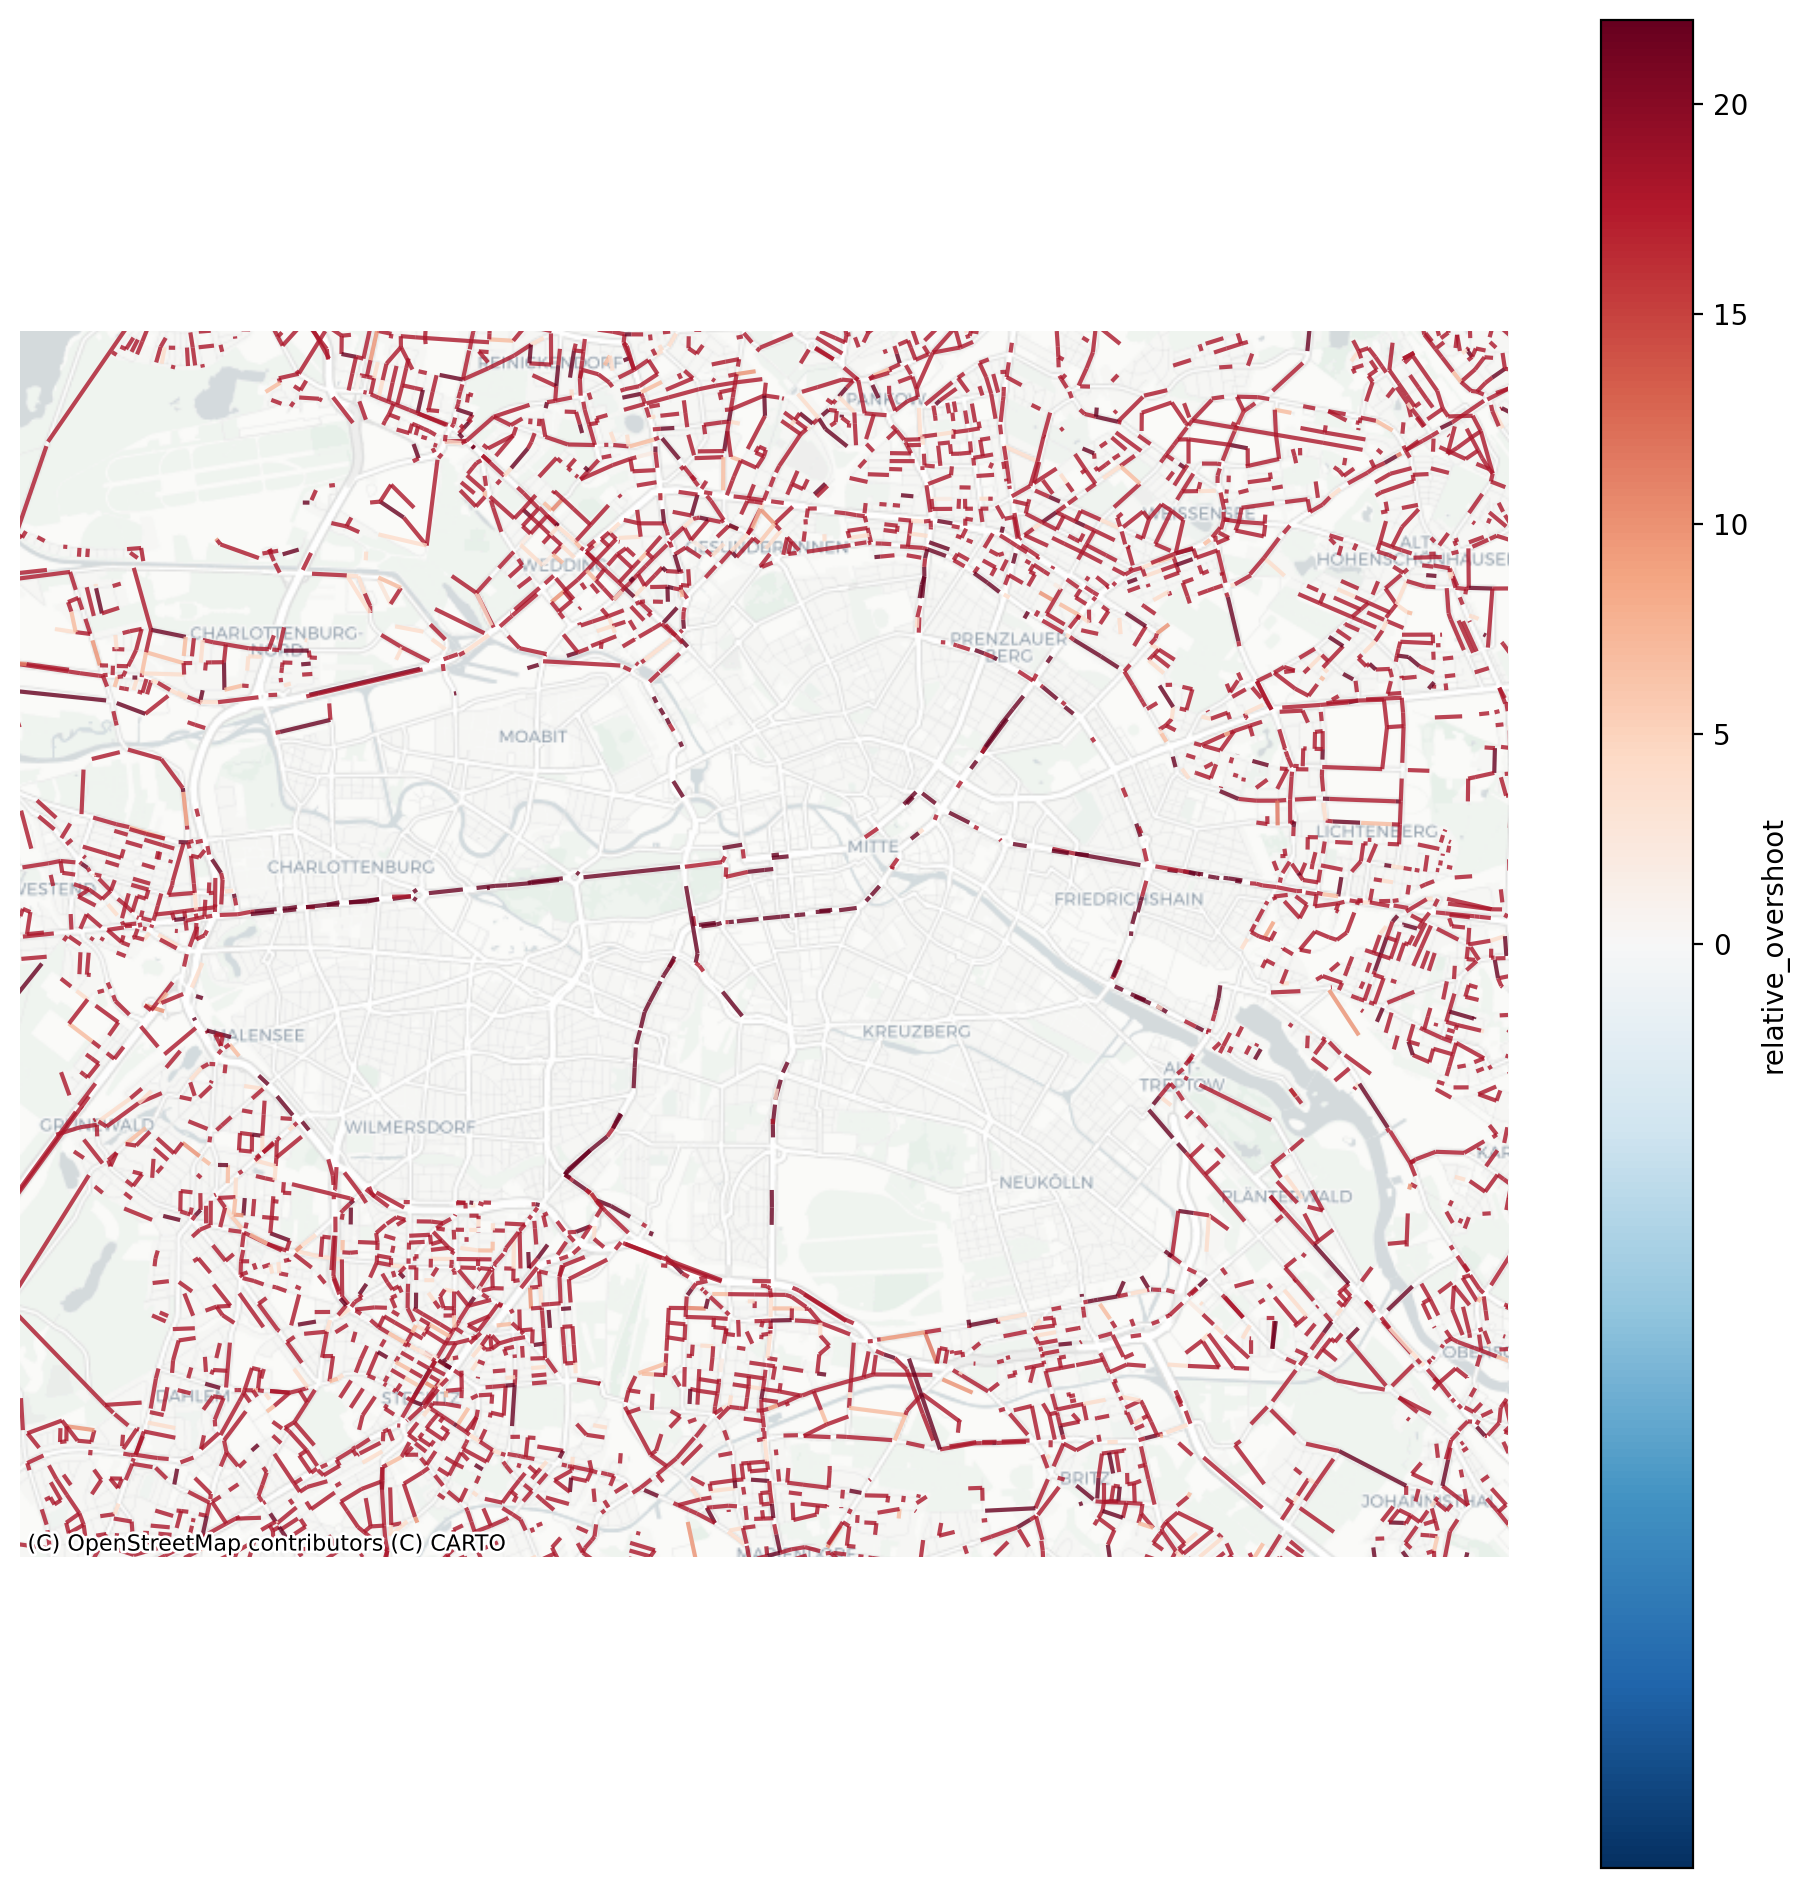

In [56]:
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
import contextily as ctx
import matplotlib.pyplot as plt
import matplotlib as mpl

bezirke = gpd.read_file("/Users/paulh/git/matsim-berlin/input/v6.4/bezirksgrenzen.geojson")
bezirke = bezirke.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(12, 12))

# symmetric range around 0
# absmax = final_3857["relative_overshoot"].abs().max()
# norm = mpl.colors.TwoSlopeNorm(vmin=-absmax, vcenter=0, vmax=absmax)

col = "relative_overshoot"
vals = pd.to_numeric(final_3857[col], errors="coerce")
vmin = vals.min()
vmax = vals.max()
norm = mpl.colors.TwoSlopeNorm(vmin=vals.min(), vcenter=0, vmax=vals.max())
cmap = plt.cm.RdBu_r

final_3857.plot(
    ax=ax,
    column="relative_overshoot",
    cmap=cmap,
    norm=norm,
    alpha=0.8,
    legend=False,
)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("relative_overshoot")

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=12)
ax.set_axis_off()

minx, miny, maxx, maxy = bezirke.total_bounds

x_diff = maxx - minx
y_diff = maxy - miny
buffer_factor = -0.3
minx -= x_diff * buffer_factor * 0.8
maxx += x_diff * buffer_factor * 1.2
miny -= y_diff * buffer_factor
maxy += y_diff * buffer_factor

ax.set_xlim([minx, maxx])
ax.set_ylim([miny, maxy])

plt.show()
